# Config 1 time-resolved: electron and ion TOF vs delay

Loads a config-1 time-resolved aggregate (`compute_aggregates.py`
with `MODE = "time_resolved"`), picks one GMD bin, and plots the
GMD-normalised eTOF and ion-TOF spectra against stage delay z.

Three figures are produced:

1. Raw GMD-normalised spectrum vs delay, eTOF and ion TOF.
2. Same with a per-delay TOF-window baseline subtracted: the mean of
   the spectrum over a chosen TOF window (defined by two TOF
   endpoints) is subtracted from every TOF bin in the same delay
   slice. Removes a DC / dark offset.
3. A region-of-interest zoom of the eTOF map (subtractions applied
   if set).

Both figures 1 and 2 optionally subtract a delay-averaged reference
spectrum, taken over a chosen delay window (`DELAY_BASELINE`).

In [ ]:
import sys
from pathlib import Path

_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import config
from compute_aggregates import load_aggregates
%matplotlib inline

## Parameters

Point `AGG_FILE` at a config-1 time-resolved aggregate. The GMD bin
is selected by integer index.

`ETOF_BASELINE_TOF` / `ION_TOF_BASELINE_TOF` give the TOF window (in
100 ps units, same as `tof_edges`) used to compute the per-delay DC
baseline subtracted in plot 2 - "subtracting two TOF bins" means
the two endpoints of that window. Set to `(None, None)` to skip.

`DELAY_BASELINE` (in stage z units, same as `z_edges`) selects a
delay window whose averaged spectrum is subtracted from every delay
slice. Set to `None` to skip.

`ETOF_ROI` (in 100 ps units) is the TOF window shown in the zoomed
plot 3. Set to `(None, None)` for the full TOF range.

In [22]:
# --- input --------------------------------------------------------
AGG_FILE = config.COMBINED_DIR / "glycine_delay_scan_150C_272.0eV_aggregates_tr.h5"

# --- GMD bin selection -------------------------------------------
GMD_BIN  = 1            # integer index into agg.gmd_edges (0..N_GMD-1)

# --- TOF-window baseline ("two TOF bins") ------------------------
# Mean over this TOF window is subtracted from every TOF bin in the
# same delay slice. Units = 100 ps (matches tof_edges).
ETOF_BASELINE_TOF    = (None, None)   # e.g. (0.0, 500.0)
ION_TOF_BASELINE_TOF = (None, None)

# --- Delay-window baseline ---------------------------------------
# Mean spectrum over this delay window is subtracted from every
# delay slice. Set to None to skip. Units = stage z.
DELAY_BASELINE = (-5000, -1000)                  # e.g. (-15000.0, -10000.0)

# --- eTOF zoom ---------------------------------------------------
ETOF_ROI = (None, None)                # e.g. (1000.0, 4000.0)

# --- cosmetics ---------------------------------------------------
PCT_LOW, PCT_HIGH = 1.0, 99.0          # robust colour-scale limits

## Load and normalise

Each spectrum is GMD-normalised by the bin mean GMD
(`D / G[:, :, None]`), giving counts-per-shot per uJ. This stops a
wide GMD bin from biasing the delay axis when the mean fluence
drifts across the scan.

In [17]:
agg = load_aggregates(AGG_FILE)

if agg.config != 1:
    raise ValueError(f"expected config=1 aggregate, got config={agg.config}")
if agg.mode != "time_resolved":
    raise ValueError(f"expected mode='time_resolved', got mode={agg.mode!r}")
if not (0 <= GMD_BIN < agg.n_gmd_bins):
    raise ValueError(
        f"GMD_BIN={GMD_BIN} out of range [0, {agg.n_gmd_bins})"
    )

tof_edges     = agg.tof_edges
ion_tof_edges = agg.ion_tof_edges
z_edges       = agg.z_edges
gmd_edges     = agg.gmd_edges

# GMD-normalised spectra at the selected GMD bin: shape (n_z, n_*).
with np.errstate(invalid="ignore", divide="ignore"):
    D = agg.D[GMD_BIN] / agg.G[GMD_BIN][:, None]
    C = agg.C[GMD_BIN] / agg.G[GMD_BIN][:, None]

gmd_label = (f"GMD [{gmd_edges[GMD_BIN]:.3g}, "
             f"{gmd_edges[GMD_BIN + 1]:.3g}) uJ")

print(f"file       : {AGG_FILE}")
print(f"GMD bin    : {GMD_BIN}  -> {gmd_label}")
print(f"n_z        : {agg.n_z_bins}")
print(f"n_tof  (e) : {agg.n_tof}")
print(f"n_tof  (i) : {agg.n_tof_i}")
print(f"shots/bin  : min={agg.n_per_bin[GMD_BIN].min()}, "
      f"max={agg.n_per_bin[GMD_BIN].max()}, "
      f"total={agg.n_per_bin[GMD_BIN].sum()}")

file       : /home/ogalex/glycine2026/glycine26/11022188/processed/combined/glycine_delay_scan_150C_272.0eV_aggregates_tr.h5
GMD bin    : 1  -> GMD [3, 6) uJ
n_z        : 48
n_tof  (e) : 1199
n_tof  (i) : 499
shots/bin  : min=17047, max=20228, total=900643


## Subtraction helpers

`_subtract_tof_baseline`: per-delay mean over a TOF window,
subtracted from every TOF bin in the same delay slice.

`_subtract_delay_baseline`: mean spectrum over a delay window,
subtracted from every delay slice. Pass `None` or `(None, None)` to
skip.

In [18]:
def _window_indices(edges, lo, hi):
    """Index range [i_lo, i_hi) of bins whose centres fall in [lo, hi)."""
    cent = 0.5 * (edges[:-1] + edges[1:])
    if lo is None:
        lo = cent[0]
    if hi is None:
        hi = cent[-1] + np.finfo(float).eps
    sel = (cent >= lo) & (cent < hi)
    idx = np.where(sel)[0]
    if idx.size == 0:
        raise ValueError(
            f"empty window [{lo}, {hi}) for edges spanning "
            f"[{edges[0]}, {edges[-1]})"
        )
    return int(idx[0]), int(idx[-1] + 1)


def _subtract_tof_baseline(spec, tof_edges, tof_window):
    if tof_window is None or tof_window == (None, None):
        return spec
    lo, hi = tof_window
    if lo is None and hi is None:
        return spec
    i0, i1 = _window_indices(tof_edges, lo, hi)
    base = np.nanmean(spec[:, i0:i1], axis=1, keepdims=True)
    return spec - base


def _subtract_delay_baseline(spec, z_edges, delay_window):
    if delay_window is None:
        return spec
    lo, hi = delay_window
    if lo is None and hi is None:
        return spec
    j0, j1 = _window_indices(z_edges, lo, hi)
    base = np.nanmean(spec[j0:j1, :], axis=0, keepdims=True)
    return spec - base


def _robust_limits(arr, pct_lo, pct_hi, symmetric=False):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1.0, 1.0
    if symmetric:
        lim = float(np.nanpercentile(np.abs(finite), pct_hi))
        if lim <= 0:
            lim = float(np.nanmax(np.abs(finite))) or 1.0
        return -lim, lim
    return (float(np.nanpercentile(finite, pct_lo)),
            float(np.nanpercentile(finite, pct_hi)))


def _plot_panel(ax, spec, x_edges, y_edges, title, xlabel, cbar_label,
                symmetric):
    if symmetric:
        vmin, vmax = _robust_limits(spec, PCT_LOW, PCT_HIGH, symmetric=True)
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        pcm = ax.pcolormesh(x_edges, y_edges, spec, cmap="RdBu_r",
                            norm=norm, shading="auto")
    else:
        vmin, vmax = _robust_limits(spec, PCT_LOW, PCT_HIGH)
        pcm = ax.pcolormesh(x_edges, y_edges, spec, cmap="viridis",
                            vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    cbar = ax.figure.colorbar(pcm, ax=ax)
    cbar.set_label(cbar_label)
    return pcm

## Plot 1 - raw GMD-normalised spectrum vs delay

eTOF on the left, ion TOF on the right. If `DELAY_BASELINE` is set,
the spectrum averaged over that delay window is subtracted from
every delay slice and a diverging colormap is used. Otherwise the
raw GMD-normalised spectrum is shown (viridis).

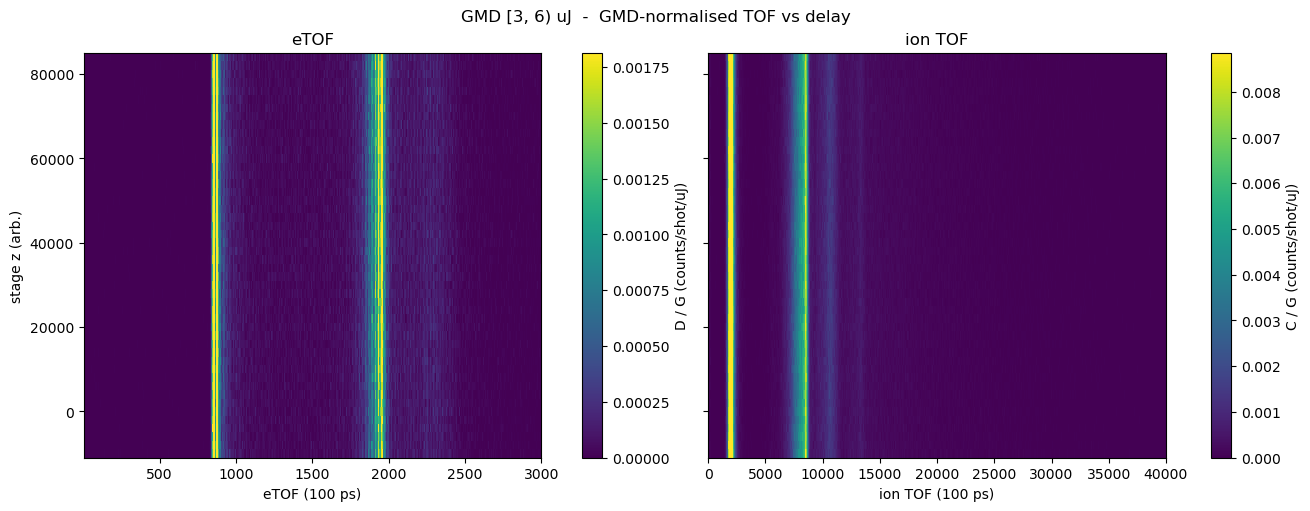

In [19]:
D_p1 = _subtract_delay_baseline(D, z_edges, DELAY_BASELINE)
C_p1 = _subtract_delay_baseline(C, z_edges, DELAY_BASELINE)

sym1 = DELAY_BASELINE is not None
suffix = "  - delay-baseline" if sym1 else ""

fig, (ax_e, ax_i) = plt.subplots(1, 2, figsize=(13, 5), sharey=True,
                                 constrained_layout=True)
_plot_panel(ax_e, D_p1, tof_edges, z_edges,
            f"eTOF{suffix}", "eTOF (100 ps)",
            "D / G (counts/shot/uJ)", sym1)
_plot_panel(ax_i, C_p1, ion_tof_edges, z_edges,
            f"ion TOF{suffix}", "ion TOF (100 ps)",
            "C / G (counts/shot/uJ)", sym1)
ax_e.set_ylabel("stage z (arb.)")
fig.suptitle(f"{gmd_label}  -  GMD-normalised TOF vs delay")
plt.show()

## Plot 2 - TOF-window baseline subtracted

For each delay slice the mean of the spectrum over the chosen TOF
window is subtracted from every TOF bin. Use this to remove a
delay-dependent DC offset (dark / scatter floor). If
`DELAY_BASELINE` is also set, the delay-averaged spectrum is
subtracted on top.

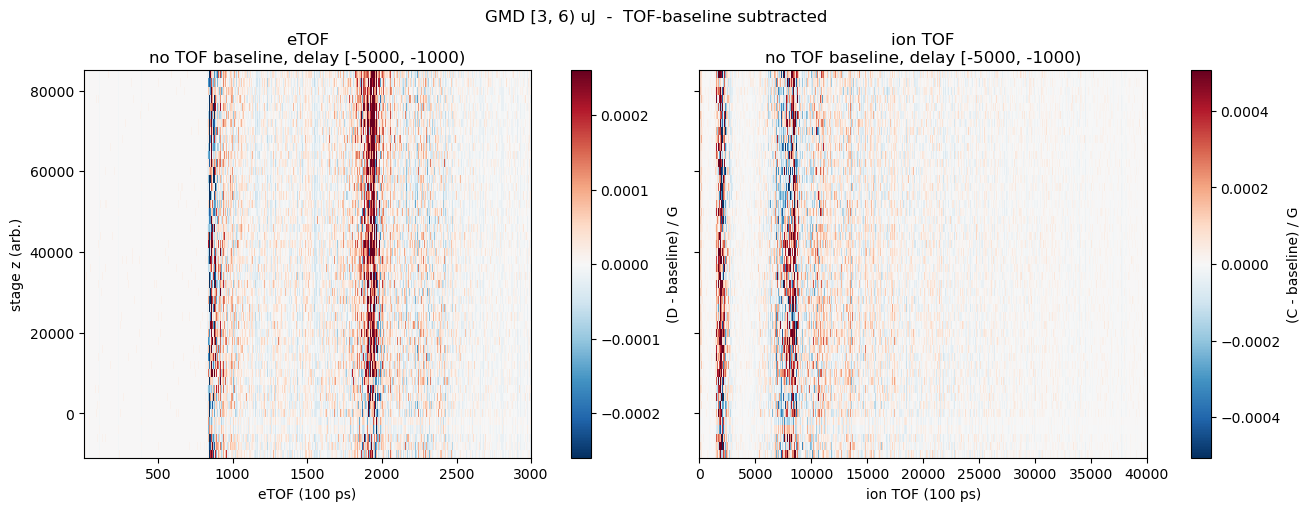

In [23]:
D_p2 = _subtract_tof_baseline(D,   tof_edges,     ETOF_BASELINE_TOF)
C_p2 = _subtract_tof_baseline(C,   ion_tof_edges, ION_TOF_BASELINE_TOF)
D_p2 = _subtract_delay_baseline(D_p2, z_edges, DELAY_BASELINE)
C_p2 = _subtract_delay_baseline(C_p2, z_edges, DELAY_BASELINE)


def _tag(window, name):
    if window == (None, None):
        return f"no {name}"
    return f"{name} [{window[0]}, {window[1]})"


delay_tag = (f", delay [{DELAY_BASELINE[0]}, {DELAY_BASELINE[1]})"
             if DELAY_BASELINE is not None else "")

fig, (ax_e, ax_i) = plt.subplots(1, 2, figsize=(13, 5), sharey=True,
                                 constrained_layout=True)
_plot_panel(ax_e, D_p2, tof_edges, z_edges,
            f"eTOF\n{_tag(ETOF_BASELINE_TOF, 'TOF baseline')}{delay_tag}",
            "eTOF (100 ps)", "(D - baseline) / G", symmetric=True)
_plot_panel(ax_i, C_p2, ion_tof_edges, z_edges,
            f"ion TOF\n{_tag(ION_TOF_BASELINE_TOF, 'TOF baseline')}{delay_tag}",
            "ion TOF (100 ps)", "(C - baseline) / G", symmetric=True)
ax_e.set_ylabel("stage z (arb.)")
fig.suptitle(f"{gmd_label}  -  TOF-baseline subtracted")
plt.show()

## Plot 3 - eTOF region-of-interest vs delay

Zooms the eTOF map into `ETOF_ROI`. All subtractions configured
above (TOF baseline + optional delay baseline) are applied.

eTOF ROI: bins [0, 1199) -> [3.0, 3000.0) 100 ps


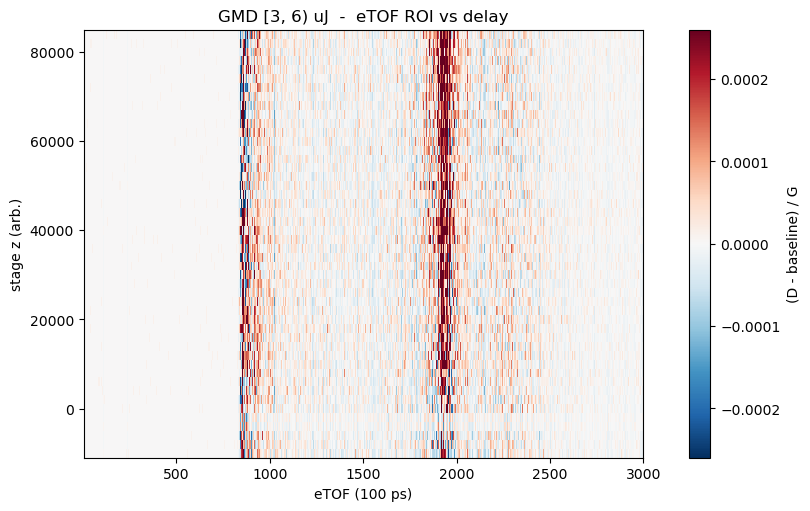

In [24]:
D_roi = _subtract_tof_baseline(D, tof_edges, ETOF_BASELINE_TOF)
D_roi = _subtract_delay_baseline(D_roi, z_edges, DELAY_BASELINE)

roi_lo, roi_hi = ETOF_ROI
if roi_lo is None and roi_hi is None:
    i0, i1 = 0, agg.n_tof
else:
    i0, i1 = _window_indices(tof_edges, roi_lo, roi_hi)
print(f"eTOF ROI: bins [{i0}, {i1}) -> "
      f"[{tof_edges[i0]:.1f}, {tof_edges[i1]:.1f}) 100 ps")

D_roi_slice = D_roi[:, i0:i1]
roi_edges   = tof_edges[i0:i1 + 1]

sym_roi = (ETOF_BASELINE_TOF != (None, None)) or (DELAY_BASELINE is not None)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
_plot_panel(
    ax, D_roi_slice, roi_edges, z_edges,
    f"{gmd_label}  -  eTOF ROI vs delay",
    "eTOF (100 ps)",
    "(D - baseline) / G" if sym_roi else "D / G (counts/shot/uJ)",
    symmetric=sym_roi,
)
ax.set_ylabel("stage z (arb.)")
plt.show()